# Automatic Tag Generation using Convolutional Neural Network (CNN)

## Project Overview

This project automatically predicts relevant tags for Stack Overflow questions using Natural Language Processing (NLP) and Deep Learning.

The model is trained on question bodies and their associated tags. A Simple CNN architecture is used to learn textual patterns and generate appropriate tags.

---

### Technologies Used

- Python
- TensorFlow / Keras
- NLP
- RNN
- Pandas
- Scikit-Learn
- Streamlit

In [1]:
import re
import pickle
import random

import numpy as np
import pandas as pd

from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Dataset Loading

The Questions dataset contains:

- ID
- OwnerUserId
- CreationDate
- Score
- Title
- Body

The Tags dataset contains:

- ID
- Tag

The objective is to learn the relationship between Questions's body and tags.

In [ ]:
questions_df = pd.read_csv("data/Questions.csv", encoding='latin-1')
tags_df = pd.read_csv("data/Tags.csv")

# Data Cleaning

Raw Stack Overflow questions contain:

- HTML tags
- Special characters
- Numbers
- Extra spaces

These elements are removed to create clean textual data.

In [7]:
def cleaner(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()

    tokens = text.split()

    return " ".join(tokens)

In [8]:
questions_df['cleaned_text'] = questions_df['Body'].apply(cleaner)

# Tag Processing

Multiple tags associated with the same question are grouped together.

Example:

Question ID 101

Tags:
- logistics
- r
- statistics

becomes

['logistics', 'r', 'statistics']

In [9]:
tags_df['Tag'] = tags_df['Tag'].apply(lambda x:re.sub("-", " ",x))
tags_df = (
    tags_df
    .groupby("Id")["Tag"]
    .apply(list)
    .reset_index(name="tags")
)

# Dataset Merging

Question bodies and corresponding tags are merged using Question IDs.

In [10]:
df = pd.merge(questions_df, tags_df, how='inner', on='Id')
df.head()

,Id,OwnerUserId,CreationDate,Score,Title,Body,cleaned_text,tags
0,6,5.0,2010-07-19T19:14:44Z,272,The Two Cultures: statistics vs. machine learn...,"<p>Last year, I read a blog post from <a href=...",last year i read a blog post from brendan o co...,[machine learning]
1,21,59.0,2010-07-19T19:24:36Z,4,Forecasting demographic census,<p>What are some of the ways to forecast demog...,what are some of the ways to forecast demograp...,"[forecasting, population, census]"
2,22,66.0,2010-07-19T19:25:39Z,208,Bayesian and frequentist reasoning in plain En...,<p>How would you describe in plain English the...,how would you describe in plain english the ch...,"[bayesian, frequentist]"
3,31,13.0,2010-07-19T19:28:44Z,138,What is the meaning of p values and t values i...,<p>After taking a statistics course and then t...,after taking a statistics course and then tryi...,"[hypothesis testing, t test, p value, interpre..."
4,36,8.0,2010-07-19T19:31:47Z,58,Examples for teaching: Correlation does not me...,"<p>There is an old saying: ""Correlation does n...",there is an old saying correlation does not me...,"[correlation, teaching]"


# Exploratory Data Analysis

Let's identify the most frequently occurring tags.

In [11]:
from collections import Counter

freq = Counter()

for tags in df["tags"]:
    freq.update(tags)

freq = dict(freq.most_common())

In [12]:
common_tags = list(freq.keys())[:10]
common_tags

['r',
 'regression',
 'machine learning',
 'time series',
 'probability',
 'hypothesis testing',
 'self study',
 'distributions',
 'logistic',
 'classification']

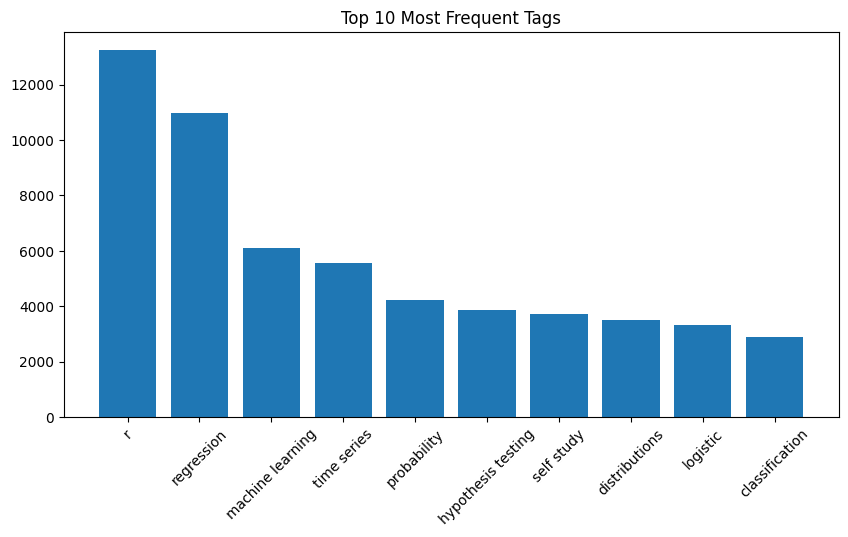

In [13]:
plt.figure(figsize=(10,5))
plt.bar(list(freq.keys())[:10], list(freq.values())[:10])
plt.xticks(rotation=45)
plt.title("Top 10 Most Frequent Tags")
plt.show()

# Filtering Relevant Samples

Only questions containing multiple popular tags are selected.

This helps create a focused multi-label classification dataset.

In [14]:
x = []
y = []

for text, tags in zip(df["cleaned_text"], df["tags"]):

    selected_tags = [
        tag for tag in tags
        if tag in common_tags
    ]

    if len(selected_tags) > 1:
        x.append(text)
        y.append(selected_tags)

# Multi Label Encoding

Tags are converted into binary vectors using MultiLabelBinarizer.

In [15]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()

y = mlb.fit_transform(y)
y.shape

(11106, 10)

# Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, shuffle=True, random_state=42)

# Tokenization and Vocabulary Creation

Text is converted into sequences of integers.

Rare words are removed to reduce noise.

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_tokenizer = Tokenizer()
x_tokenizer.fit_on_texts(x_train)

In [19]:
thresh = 3

cnt = sum(
    1
    for value in x_tokenizer.word_counts.values()
    if value >= thresh
)

In [20]:
x_tokenizer =  Tokenizer(num_words=cnt, oov_token='unk')
x_tokenizer.fit_on_texts(x_train)

# Sequence Padding

All sequences are padded to a fixed length to ensure consistent model input dimensions.

In [21]:
max_len = 100

x_train_seq = x_tokenizer.texts_to_sequences(x_train)
x_val_seq = x_tokenizer.texts_to_sequences(x_test)

x_train_seq = pad_sequences(x_train_seq, padding='post', maxlen=max_len)
x_val_seq = pad_sequences(x_val_seq, maxlen=max_len, padding="post")

In [22]:
x_voc_size = x_tokenizer.num_words + 1
x_voc_size

12500

# CNN Model Architecture

In [36]:
from keras.models import *
from keras.layers import *
from keras.callbacks import *
from keras.optimizers import Adam

In [60]:
model = Sequential()
model.add(Embedding(x_voc_size, 50, input_shape=(max_len,), mask_zero=True))

model.add(Conv1D(64, 3, padding='same'))
model.add(Dropout(0.1))

model.add(GlobalMaxPooling1D())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [61]:
adam = Adam(learning_rate=0.01)
model.compile(
    optimizer=adam,
    loss="binary_crossentropy"
)

# Model Training

In [ ]:
mc = ModelCheckpoint("models/cnn/auto_tag_model.h5", monitor="val_loss", verbose=1, save_best_only=True, mode='min')
model.fit(x_train_seq, y_train, validation_data=(x_val_seq, y_test), epochs=10, callbacks=[mc], verbose=1, batch_size=128)

# Model Evaluation

Predictions are generated on the validation dataset.

Optimal threshold selection is performed using F1 Score.

In [64]:
model.load_weights("models/cnn/auto_tag_model.h5")

pred_prob = model.predict(x_val_seq)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [65]:
threshold = np.arange(0, 0.5, 0.01)

def classify(pred_prob, thresh):
  y_pred_seq = []

  for i in pred_prob:
    temp = []
    for j in i:
      if j>thresh:
        temp.append(1)
      else:
        temp.append(0)
    y_pred_seq.append(temp)

  return y_pred_seq

In [66]:
from sklearn import metrics
score = []

y_true = np.array(y_test).ravel()

for thresh in threshold:

  y_pred_seq = classify(pred_prob, thresh)
  y_pred_seq = np.array(y_pred_seq).ravel()

  score.append(metrics.f1_score(y_true, y_pred_seq))

opt = threshold[score.index(max(score))]
y_pred_seq = classify(pred_prob, opt)
y_pred = np.array(y_pred_seq).ravel()

# Classification Report

In [67]:
print(metrics.classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92     17509
           1       0.70      0.77      0.73      4711

    accuracy                           0.88     22220
   macro avg       0.82      0.84      0.83     22220
weighted avg       0.89      0.88      0.88     22220



# Sample Predictions

In [68]:
y_pred_seq = np.array(y_pred_seq)
y_pred = mlb.inverse_transform(y_pred_seq)
y_test_transformed = mlb.inverse_transform(y_test)

df = pd.DataFrame(({'comment':x_test, 'actual':y_test_transformed, 'predictions':y_pred}))

In [69]:
df.sample(10)

,comment,actual,predictions
1919,i have two time series and i want to check the...,"(r, regression, time series)","(r, regression, time series)"
2206,i m trying to code my own quasi newton algorit...,"(r, regression)","(regression,)"
1452,i want to measure the inner correlation of the...,"(r, time series)","(r, time series)"
700,i am involved in a project where i need to che...,"(distributions, hypothesis testing)","(distributions, hypothesis testing)"
1277,i am developing a small web application with r...,"(r, time series)","(hypothesis testing, r, time series)"
417,would someone mind walking me through the diff...,"(regression, time series)","(regression, time series)"
1382,this is kind of a follow up question from this...,"(r, regression)","(r, regression)"
873,i am trying to learn about methods for learnin...,"(classification, probability)","(classification, logistic, machine learning, p..."
1514,i m trying to get a predictive density and cur...,"(probability, self study)","(probability, self study)"
1417,i was wondering what kind of tests one would u...,"(r, time series)","(r, time series)"


# Custom Inference Function

In [70]:
def predict_tag(comment):
  text = []
  text = [cleaner(comment)]
  seq = x_tokenizer.texts_to_sequences(text)
  pad_seq = pad_sequences(seq, padding='post', maxlen=max_len)
  pred_prob = model.predict(pad_seq)
  classes = classify(pred_prob, opt)[0]

  classes = np.array([classes])
  classes = mlb.inverse_transform(classes)

  return classes

# Example Prediction

In [71]:
comment = "I am working with a dataset of monthly sales and I want to forecast the next 12 months using an ARIMA model in R."
predicted_tags = predict_tag(comment)
print(f"The comment: '{comment}'\nPredicted Tags: {predicted_tags}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The comment: 'I am working with a dataset of monthly sales and I want to forecast the next 12 months using an ARIMA model in R.'
Predicted Tags: [('r', 'time series')]


# Saving Artifacts

The trained model, tokenizer, and label encoder are saved for deployment.

In [ ]:
with open("models/tokenizer.pkl","wb") as f:
    pickle.dump(x_tokenizer,f)

with open("models/mlb.pkl","wb") as f:
    pickle.dump(mlb,f)

In [73]:
model.save_weights("models/cnn/weights_best.weights.h5")